# Real Estate Valuation - Linear Regression
Analysis of Real Estate Valuation using Linear, Ridge, and Lasso Regression.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Ensure openpyxl is installed for reading Excel files
try:
    import openpyxl
except ImportError:
    !pip install openpyxl

In [74]:
# 1. Load the dataset
try:
    df = pd.read_excel('Real estate valuation data set.xlsx')
    print("Dataset loaded successfully.")
    print("Original Shape:", df.shape)
    display(df.head())
except FileNotFoundError:
    print("File not found. Please ensure 'Real estate valuation data set.xlsx' is in the directory.")

Dataset loaded successfully.
Original Shape: (414, 8)


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [75]:
# 2. Pre-processing
# Remove the first column (No/ID) and first row (if instructed, likely index 0)

# Removing first column
if 'No' in df.columns or df.shape[1] > 6: # Heuristic check
    df_clean = df.drop(df.columns[0], axis=1)
else:
    df_clean = df.copy()

# Removing first row (index 0) - Per instruction "remove the first row"
# df_clean.columns = df_clean.iloc[0]
# df_clean = df_clean.iloc[1:].reset_index(drop=True)

print("Shape after cleaning:", df_clean.shape)
display(df_clean.head())

Shape after cleaning: (414, 7)


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [76]:
# Define Features (X) and Target (Y)
# Assuming last column is Y
X = df_clean.iloc[:, :-1]
y = df_clean.iloc[:, -1]

# 3. Split dataset 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (331, 6), Test shape: (83, 6)


In [77]:
# 4. Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# 5. Report coefficients and intercept
print("Intercept:", lr.intercept_)
print("Coefficients:")
for feat, coef in zip(X.columns, lr.coef_):
    print(f"{feat}: {coef}")

Intercept: -13048.14337937102
Coefficients:
X1 transaction date: 5.443262420219845
X2 house age: -0.2707942969936167
X3 distance to the nearest MRT station: -0.004758683101625327
X4 number of convenience stores: 1.0914692248362106
X5 latitude: 229.04904348184309
X6 longitude: -29.503389488224013


In [78]:
# 6. Predict on test dataset
y_pred = lr.predict(X_test)

# 7. Compute MSE and R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 53.5023
R2 Score: 0.6811


In [79]:
# 8. Repeat for other splits
splits = {
    '60:40': 0.4,
    '70:30': 0.3,
    '90:10': 0.1
}

print("\n--- Performance on Different Splits ---")
for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    yp = model.predict(X_te)
    m = mean_squared_error(y_te, yp)
    r = r2_score(y_te, yp)
    print(f"Split {split_name} -> MSE: {m:.4f}, R2: {r:.4f}")


--- Performance on Different Splits ---
Split 60:40 -> MSE: 64.9759, R2: 0.5688
Split 70:30 -> MSE: 73.5655, R2: 0.5601
Split 90:10 -> MSE: 70.7113, R2: 0.6392


In [80]:
# 9. Ridge and Lasso Regression for various alphas
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
all_splits = {'80:20': 0.2, **splits}

results = []

for split_name, test_size in all_splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)
    
    for alpha in alphas:
        # Ridge
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_tr, y_tr)
        yp_r = ridge.predict(X_te)
        results.append({
            'Split': split_name,
            'Model': 'Ridge',
            'Alpha': alpha,
            'MSE': mean_squared_error(y_te, yp_r),
            'R2': r2_score(y_te, yp_r)
        })
        
        # Lasso
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_tr, y_tr)
        yp_l = lasso.predict(X_te)
        results.append({
            'Split': split_name,
            'Model': 'Lasso',
            'Alpha': alpha,
            'MSE': mean_squared_error(y_te, yp_l),
            'R2': r2_score(y_te, yp_l)
        })

results_df = pd.DataFrame(results)
display(results_df)

,Split,Model,Alpha,MSE,R2
0,80:20,Ridge,0.001,53.464252,0.681305
1,80:20,Lasso,0.001,53.309975,0.682224
2,80:20,Ridge,0.005,53.380625,0.681803
3,80:20,Lasso,0.005,53.084664,0.683567
4,80:20,Ridge,0.010,53.373818,0.681844
5,80:20,Lasso,0.010,53.382653,0.681791
6,80:20,Ridge,0.050,54.039821,0.677874
7,80:20,Lasso,0.050,56.164106,0.665211
8,80:20,Ridge,0.100,54.642195,0.674283
9,80:20,Lasso,0.100,56.286399,0.664482


In [81]:
# 10. Validation Set for Best Parameter
# Split Train data (from 80:20 initial split) into Train/Validation (80:20)
# Use X_train, y_train from Step 3

X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

best_alpha_ridge = None
best_mse_ridge = float('inf')
best_alpha_lasso = None
best_mse_lasso = float('inf')

print("--- Validation for Best Alpha ---")

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_sub, y_train_sub)
    mse_r = mean_squared_error(y_val, ridge.predict(X_val))
    if mse_r < best_mse_ridge:
        best_mse_ridge = mse_r
        best_alpha_ridge = alpha

    # Lasso
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_sub, y_train_sub)
    mse_l = mean_squared_error(y_val, lasso.predict(X_val))
    if mse_l < best_mse_lasso:
        best_mse_lasso = mse_l
        best_alpha_lasso = alpha

print(f"Best Ridge Alpha: {best_alpha_ridge} with MSE: {best_mse_ridge:.4f}")
print(f"Best Lasso Alpha: {best_alpha_lasso} with MSE: {best_mse_lasso:.4f}")

--- Validation for Best Alpha ---
Best Ridge Alpha: 0.005 with MSE: 60.3039
Best Lasso Alpha: 0.005 with MSE: 60.1312


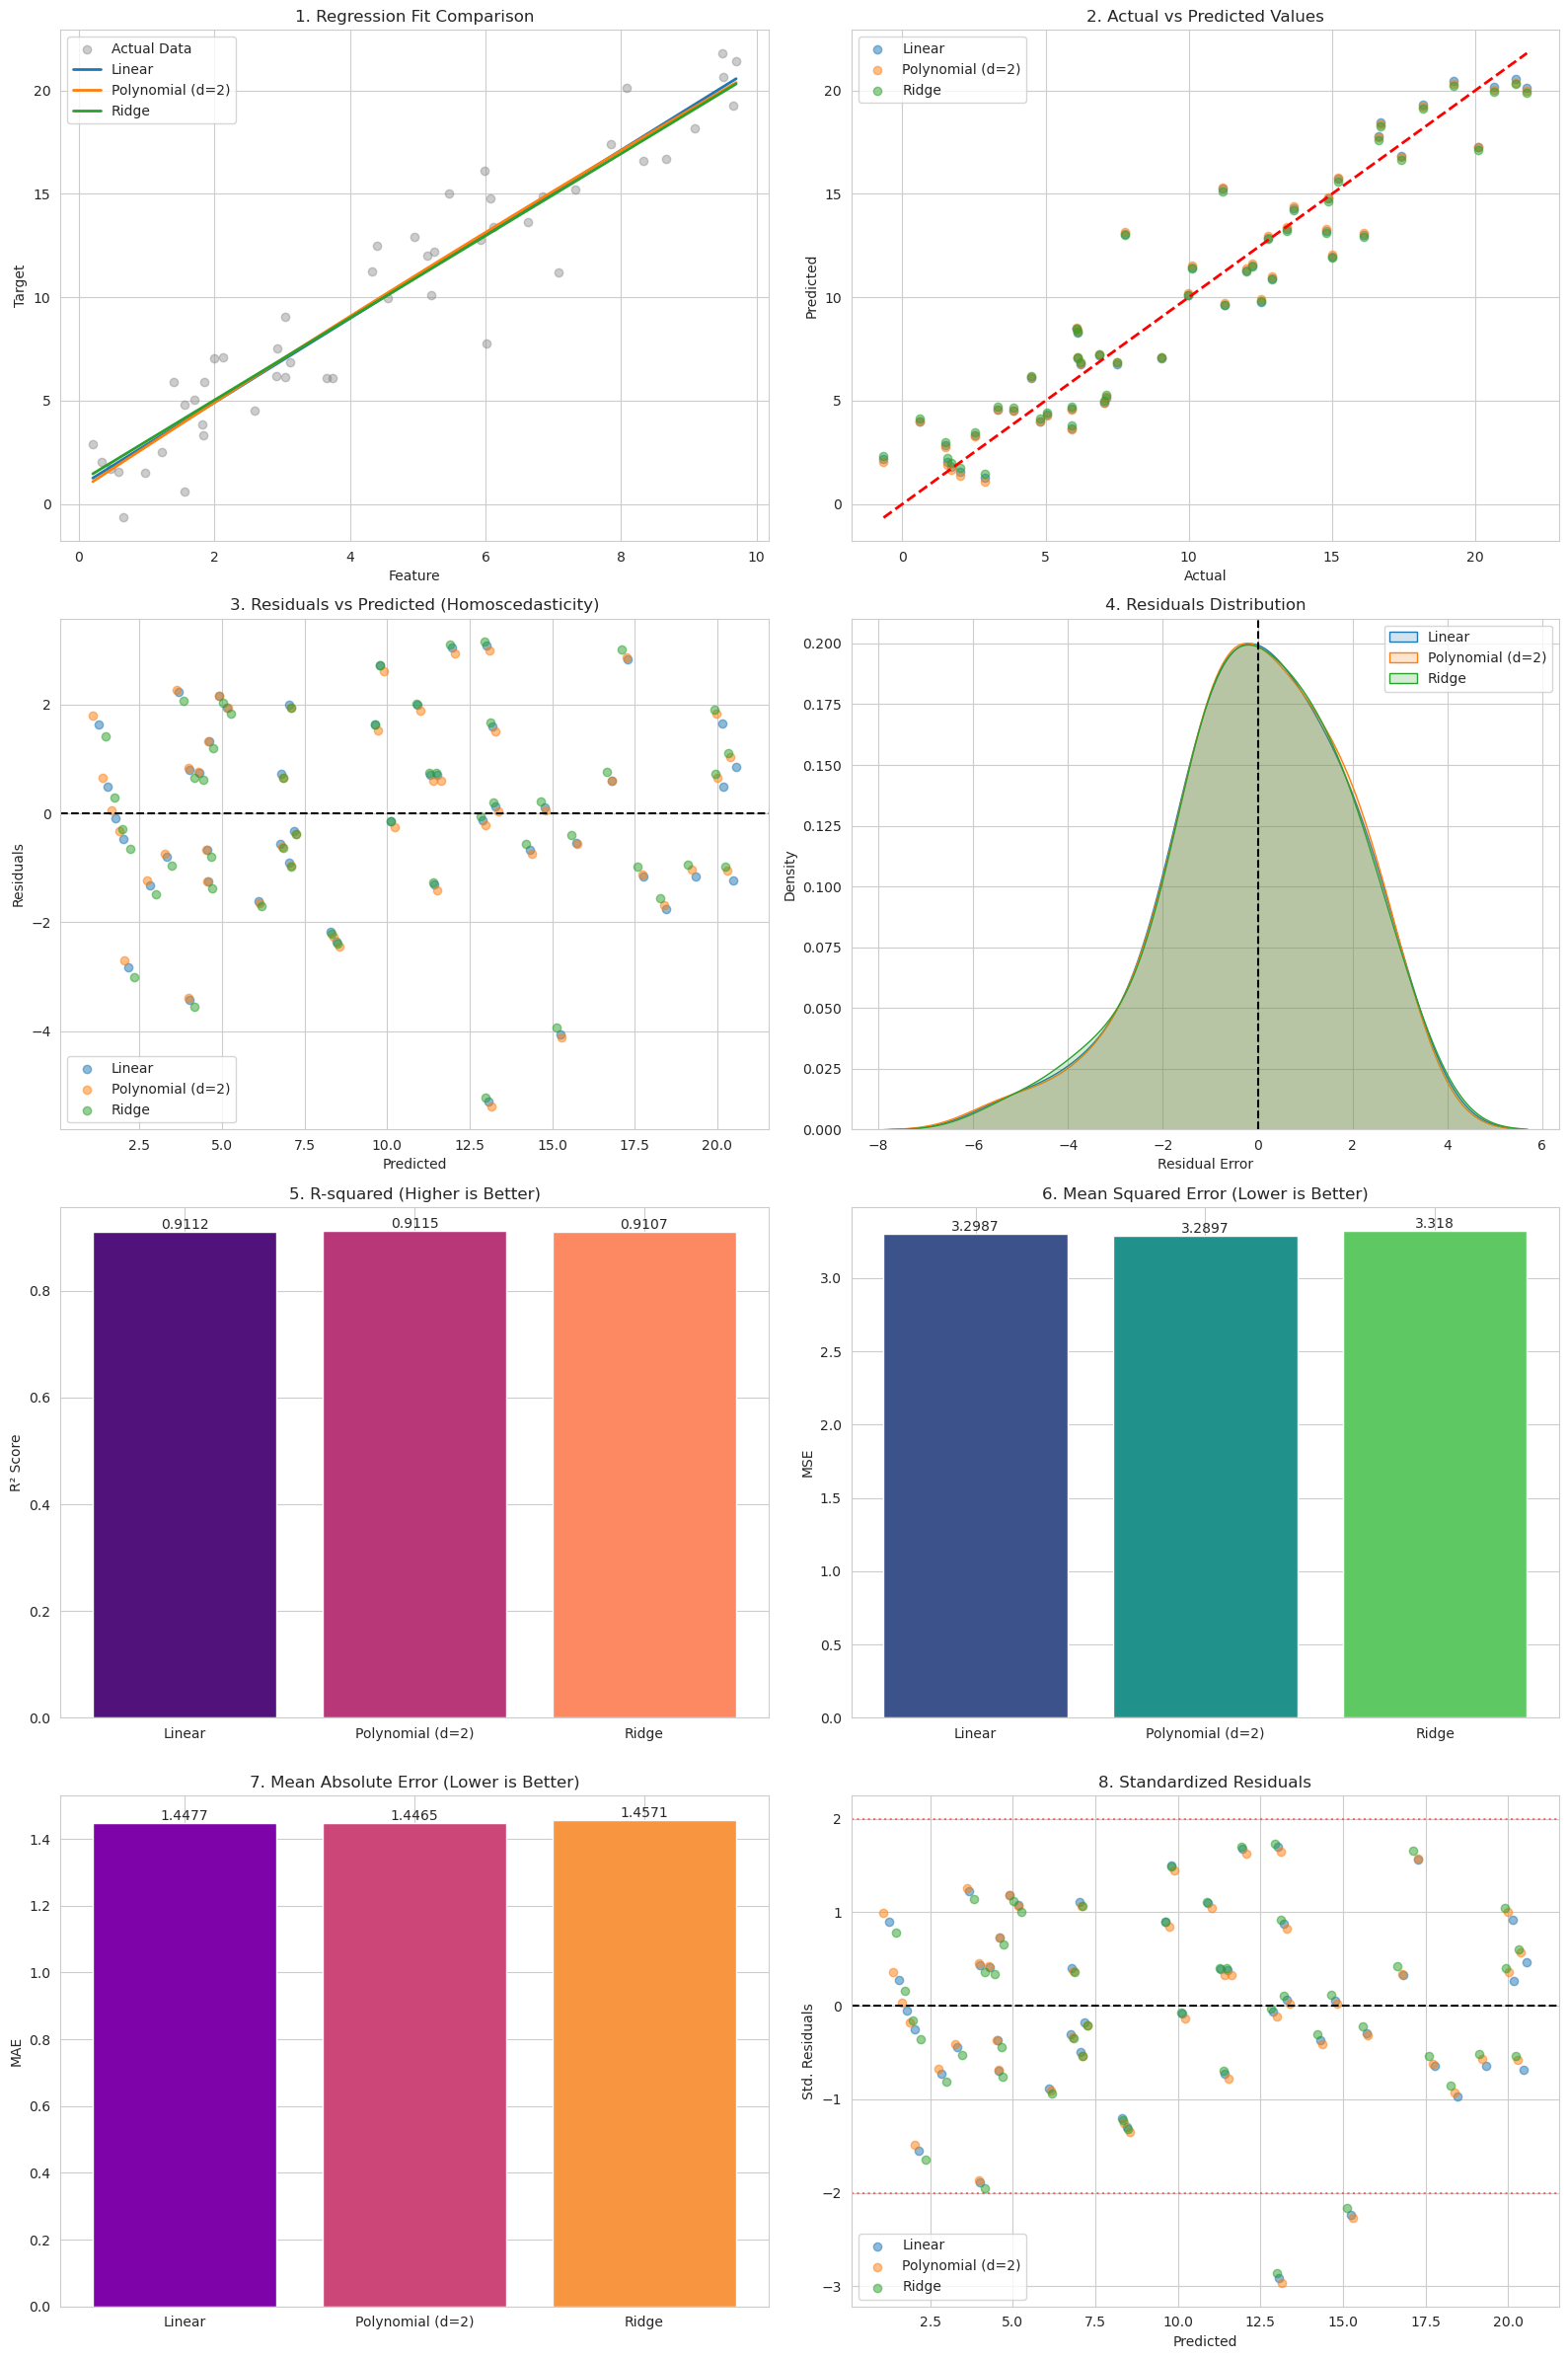

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

def compare_regression_models(X, y, models, model_names):
    """
    Generates an extensive suite of plots to compare regression models and validate assumptions.
    """
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(4, 2, figsize=(16, 24))
    axes = axes.flatten()
    
    # 1. Regression Fit Comparison (1D)
    axes[0].scatter(X, y, color='gray', alpha=0.4, label='Actual Data')
    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    for model, name in zip(models, model_names):
        y_plot = model.predict(X_plot)
        axes[0].plot(X_plot, y_plot, label=f'{name}', linewidth=2)
    axes[0].set_title('1. Regression Fit Comparison')
    axes[0].set_xlabel('Feature')
    axes[0].set_ylabel('Target')
    axes[0].legend()

    # 2. Actual vs Predicted (Identity Line)
    for model, name in zip(models, model_names):
        y_pred = model.predict(X)
        axes[1].scatter(y, y_pred, alpha=0.5, label=name)
    axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    axes[1].set_title('2. Actual vs Predicted Values')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].legend()

    # 3. Residuals vs Predicted (Homoscedasticity Check)
    for model, name in zip(models, model_names):
        y_pred = model.predict(X)
        residuals = y - y_pred
        axes[2].scatter(y_pred, residuals, alpha=0.5, label=name)
    axes[2].axhline(0, color='black', linestyle='--')
    axes[2].set_title('3. Residuals vs Predicted (Homoscedasticity)')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Residuals')
    axes[2].legend()

    # 4. Residual Distribution (Normality Check)
    for model, name in zip(models, model_names):
        y_pred = model.predict(X)
        residuals = y - y_pred
        sns.kdeplot(residuals, ax=axes[3], label=name, fill=True, alpha=0.2)
    axes[3].axvline(0, color='black', linestyle='--')
    axes[3].set_title('4. Residuals Distribution')
    axes[3].set_xlabel('Residual Error')
    axes[3].legend()

    # 5. R-squared Comparison
    r2_scores = [r2_score(y, model.predict(X)) for model in models]
    bars = axes[4].bar(model_names, r2_scores, color=sns.color_palette("magma", len(models)))
    axes[4].set_title('5. R-squared (Higher is Better)')
    axes[4].set_ylabel('R² Score')
    for bar in bars:
        yval = bar.get_height()
        axes[4].text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), va='bottom', ha='center')

    # 6. Mean Squared Error (MSE)
    mses = [mean_squared_error(y, model.predict(X)) for model in models]
    bars = axes[5].bar(model_names, mses, color=sns.color_palette("viridis", len(models)))
    axes[5].set_title('6. Mean Squared Error (Lower is Better)')
    axes[5].set_ylabel('MSE')
    for bar in bars:
        yval = bar.get_height()
        axes[5].text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), va='bottom', ha='center')

    # 7. Mean Absolute Error (MAE)
    maes = [mean_absolute_error(y, model.predict(X)) for model in models]
    bars = axes[6].bar(model_names, maes, color=sns.color_palette("plasma", len(models)))
    axes[6].set_title('7. Mean Absolute Error (Lower is Better)')
    axes[6].set_ylabel('MAE')
    for bar in bars:
        yval = bar.get_height()
        axes[6].text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), va='bottom', ha='center')

    # 8. Standardized Residuals (Outlier Detection)
    for model, name in zip(models, model_names):
        y_pred = model.predict(X)
        residuals = y - y_pred
        std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
        axes[7].scatter(y_pred, std_residuals, alpha=0.5, label=name)
    axes[7].axhline(0, color='black', linestyle='--')
    axes[7].axhline(2, color='red', linestyle=':', alpha=0.5)
    axes[7].axhline(-2, color='red', linestyle=':', alpha=0.5)
    axes[7].set_title('8. Standardized Residuals')
    axes[7].set_xlabel('Predicted')
    axes[7].set_ylabel('Std. Residuals')
    axes[7].legend()

    plt.tight_layout()
    plt.show()

# Example usage with synthetic data
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
X_train = np.sort(10 * np.random.rand(50, 1), axis=0)
y_train = 2 * X_train.ravel() + 1 + np.random.normal(0, 2, 50)

lin_reg = LinearRegression().fit(X_train, y_train)
poly_reg = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(X_train, y_train)
ridge_reg = Ridge(alpha=10).fit(X_train, y_train)

compare_regression_models(X_train, y_train, 
                         [lin_reg, poly_reg, ridge_reg], 
                         ['Linear', 'Polynomial (d=2)', 'Ridge'])
